In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.metrics import mean_squared_error

lasso_pred = lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, lasso_pred)

print("LASSO MSE:", mse_lasso)

LASSO MSE: 944909334.8149974


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso

In [14]:
data = pd.read_csv("train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [15]:
y = data["SalePrice"]

X = data.drop(["SalePrice", "Id"], axis=1)

In [16]:
X = pd.get_dummies(X)

In [17]:
X = X.fillna(0)

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
def dynamic_lasso(X, y, lr=0.001, lambda0=0.1, alpha=0.01, iterations=500):

    n, d = X.shape
    
    w = np.zeros(d)
    
    loss_history = []
    
    for k in range(iterations):
        
        # Gradient of MSE
        gradient = (1/n) * X.T.dot(X.dot(w) - y)
        
        # Dynamic threshold
        lambda_k = lambda0 / (1 + alpha * k)
        
        # Gradient step
        z = w - lr * gradient
        
        # Soft thresholding
        w = np.sign(z) * np.maximum(np.abs(z) - lr * lambda_k, 0)
        
        # Compute loss
        predictions = X.dot(w)
        loss = np.mean((predictions - y)**2)
        
        loss_history.append(loss)
        
    return w, loss_history

In [21]:
start = time.time()

weights, loss_history = dynamic_lasso(X_train, y_train)

end = time.time()

dynamic_runtime = end - start

In [22]:
y_pred_dynamic = X_test.dot(weights)

In [23]:
mse_dynamic = mean_squared_error(y_test, y_pred_dynamic)

print("Dynamic LASSO MSE:", mse_dynamic)

Dynamic LASSO MSE: 38685844301.0687


In [24]:
selected_features = np.sum(weights != 0)

print("Number of selected features:", selected_features)

Number of selected features: 287


In [25]:
start = time.time()

ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

end = time.time()

ridge_runtime = end - start

In [26]:
ridge_pred = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, ridge_pred)

print("Ridge MSE:", mse_ridge)

Ridge MSE: 854234303.4498901


In [27]:
ridge_features = np.sum(ridge.coef_ != 0)

print("Ridge Features:", ridge_features)

Ridge Features: 287


In [36]:
import time
from sklearn.linear_model import Lasso

start = time.time()

lasso = Lasso(
    alpha=0.05,
    max_iter=50000,
    tol=0.1
)

lasso.fit(X_train, y_train)

end = time.time()

lasso_runtime = end - start

print("LASSO Runtime:", lasso_runtime)

LASSO Runtime: 0.014093160629272461


In [37]:
lasso_pred = lasso.predict(X_test)

In [38]:
lasso_features = np.sum(lasso.coef_ != 0)

print("LASSO Selected Features:", lasso_features)

LASSO Selected Features: 284


In [41]:
results = pd.DataFrame({

    "Model": ["Ridge", "LASSO", "Dynamic LASSO"],

    "MSE": [mse_ridge, mse_lasso, mse_dynamic],

    "Selected Features": [
        ridge_features,
        lasso_features,
        selected_features
    ],

    "Runtime": [
        ridge_runtime,
        lasso_runtime,
        dynamic_runtime
    ]

})

results

,Model,MSE,Selected Features,Runtime
0,Ridge,8.542343e+08,287,0.125989
1,LASSO,9.449093e+08,284,0.014093
2,Dynamic LASSO,3.868584e+10,287,1.369362


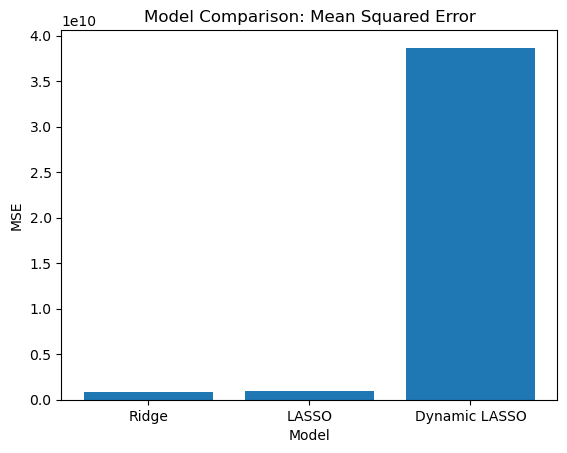

In [42]:
import matplotlib.pyplot as plt

models = ["Ridge", "LASSO", "Dynamic LASSO"]
mse_values = [mse_ridge, mse_lasso, mse_dynamic]

plt.figure()

plt.bar(models, mse_values)

plt.title("Model Comparison: Mean Squared Error")
plt.xlabel("Model")
plt.ylabel("MSE")

plt.show()

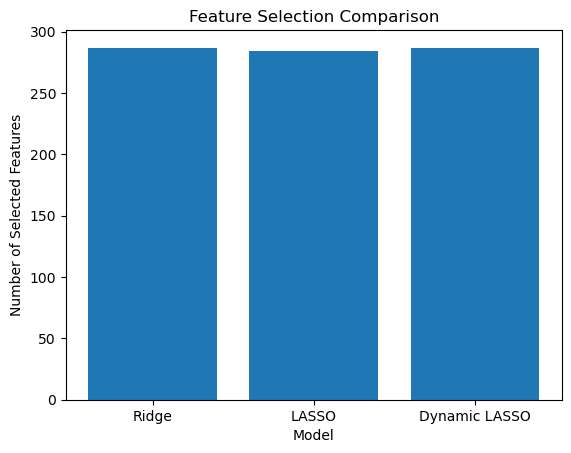

In [43]:
features = [ridge_features, lasso_features, selected_features]

plt.figure()

plt.bar(models, features)

plt.title("Feature Selection Comparison")
plt.xlabel("Model")
plt.ylabel("Number of Selected Features")

plt.show()

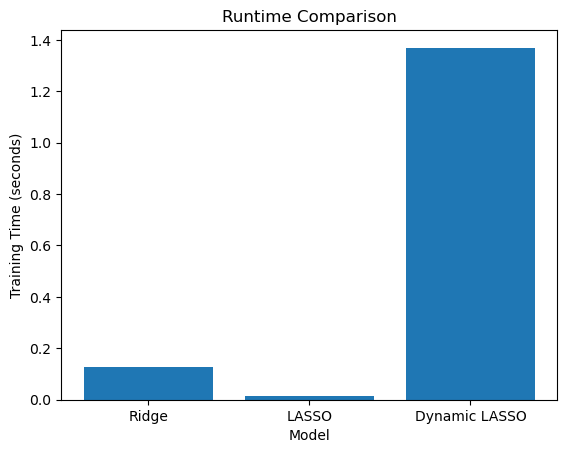

In [44]:
runtimes = [ridge_runtime, lasso_runtime, dynamic_runtime]

plt.figure()

plt.bar(models, runtimes)

plt.title("Runtime Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.show()

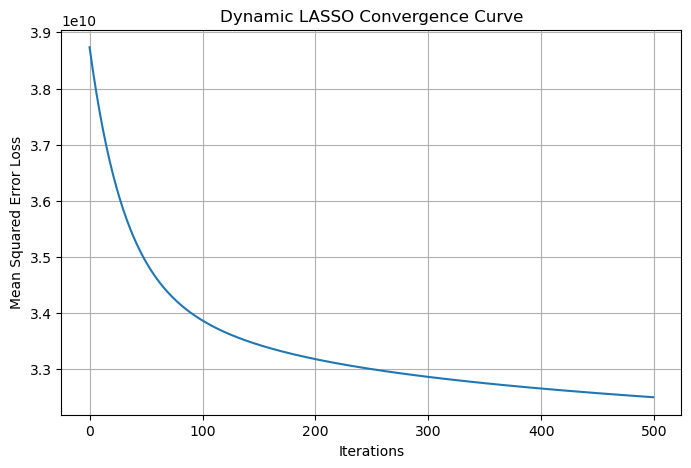

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Dynamic LASSO Convergence Curve")

plt.xlabel("Iterations")

plt.ylabel("Mean Squared Error Loss")

plt.grid(True)

plt.show()

In [45]:
feature_names = X.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": weights
})

important_features = coef_df[coef_df["Coefficient"] != 0]

important_features = important_features.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

important_features.head(10)

,Feature,Coefficient
3,OverallQual,6405.191035
15,GrLivArea,6284.144202
22,TotRmsAbvGrd,5096.234713
12,1stFlrSF,5068.215270
25,GarageCars,4790.096663
181,BsmtQual_Ex,4525.838838
11,TotalBsmtSF,4433.783326
26,GarageArea,4293.065632
28,OpenPorchSF,4281.940693
18,FullBath,3890.398235


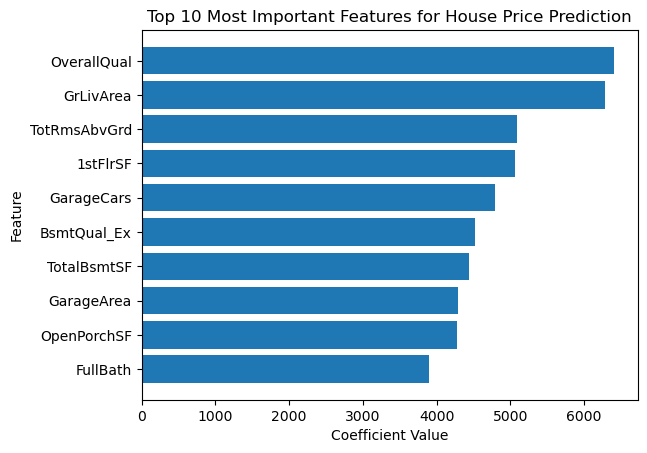

In [46]:
top_features = important_features.head(10)

plt.figure()

plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.title("Top 10 Most Important Features for House Price Prediction")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [47]:
print("===== FINAL MODEL COMPARISON =====")

print(results)

print("\nTop 10 Important Features:")

print(top_features)

===== FINAL MODEL COMPARISON =====
           Model           MSE  Selected Features   Runtime
0          Ridge  8.542343e+08                287  0.125989
1          LASSO  9.449093e+08                284  0.014093
2  Dynamic LASSO  3.868584e+10                287  1.369362

Top 10 Important Features:
          Feature  Coefficient
3     OverallQual  6405.191035
15      GrLivArea  6284.144202
22   TotRmsAbvGrd  5096.234713
12       1stFlrSF  5068.215270
25     GarageCars  4790.096663
181   BsmtQual_Ex  4525.838838
11    TotalBsmtSF  4433.783326
26     GarageArea  4293.065632
28    OpenPorchSF  4281.940693
18       FullBath  3890.398235
